In [1]:
import pandas as pd
import geopandas as gpd
import rioxarray
from shapely.geometry import box, Point
import cv2
import matplotlib.pyplot as plt
from georefcam.camera_model import CTCameraModel
from georefcam.dem import RasterioDEM
from georefcam.georefcam import GeoRefCam, get_direction_vector
import numpy as np
import pyvista as pv
import rioxarray
from PIL import Image
import glob
import os
import ncnn
from tqdm import tqdm
from sklearn.metrics import mean_squared_error
from dem_utils import compute_dem_bbox_from_point, download_dem_eio, reproject_and_save_dem

In [2]:
# --- NaN-safe normalization for any input ---
def safe_normalize(arr, th_min=0, th_max=100, scale=255.0):
    mask = ~np.isnan(arr)
    if not np.any(mask):
        return np.zeros_like(arr, dtype="float32")

    min_val = np.nanpercentile(arr, th_min)
    max_val = np.nanpercentile(arr, th_max)
    if max_val - min_val == 0:
        return np.zeros_like(arr, dtype="float32")

    norm = (arr - min_val) / (max_val - min_val)
    norm = np.clip(norm, 0, 1)

    result = np.zeros_like(arr, dtype="float32")
    result[mask] = norm[mask] * scale
    return result




In [3]:
def extract_skyline(image):
    h, w = image.shape[:2]
    # Resize to input size and convert BGR to RGB
    resized = cv2.resize(image, (384, 384))
    rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

    # Convert to NCNN Mat
    in_mat = ncnn.Mat.from_pixels(rgb, ncnn.Mat.PixelType.PIXEL_RGB, 384, 384)

    # Normalize
    mean_vals = [0.485 * 255.0, 0.456 * 255.0, 0.406 * 255.0]
    norm_vals = [1.0 / (0.229 * 255.0), 1.0 / (0.224 * 255.0), 1.0 / (0.225 * 255.0)]
    in_mat.substract_mean_normalize(mean_vals, norm_vals)
    # Run inference
    ex = skynet.create_extractor()
    ex.set_light_mode(True)
    ex.set_num_threads(4)
    ex.input("input.1", in_mat)

    out = ncnn.Mat()
    ex.extract("1959", out)

    # Convert NCNN Mat to NumPy array directly
    out_np = np.array(out)  # No .data or .to_numpy needed

    # Confirm shape and dtype
    print(out_np.shape, out_np.dtype)  # Should be (384, 384)

    # Resize back to original image size
    return cv2.resize(out_np[0], (w, h), interpolation=cv2.INTER_LINEAR)

In [4]:
skynet = ncnn.Net()
skynet.opt.use_vulkan_compute = True
skynet.opt.num_threads=4
skynet.load_param("skyline_model/skysegsmall_sim-opt-fp16.param")
skynet.load_model("skyline_model/skysegsmall_sim-opt-fp16.bin")

[0 Apple M4 Pro]  queueC=0[1]  queueG=0[1]  queueT=0[1]
[0 Apple M4 Pro]  bugsbn1=0  bugbilz=0  bugcopc=0  bugihfa=0
[0 Apple M4 Pro]  fp16-p/s/u/a=1/1/1/1  int8-p/s/u/a=1/1/1/1
[0 Apple M4 Pro]  subgroup=32(4~32)  ops=1/1/1/1/1/1/0/1/0/0
[0 Apple M4 Pro]  fp16-8x8x16/16x8x8/16x8x16/16x16x16=0/0/0/0


0

In [105]:
test_img_res

(1280, 720)

: 

In [5]:
sites_data = pd.read_csv("data/sites.csv")
sites_data

,name,lat,lon,elevation,fov_x,fov_y
0,brison,44.545155,4.216534,830,87,44
1,marguerite,44.688492,4.313501,984,87,44
2,cabanelle,43.786647,7.419608,1080,87,44
3,courmettes,43.715592,7.026486,800,87,44
4,valbonne,43.623364,7.027940,200,87,44
5,croix-augas,48.426746,2.710876,150,54,44


In [6]:
# lat, lon = 44.545193329667704, 4.216420359525704

In [7]:
images = glob.glob("data/images/*")
images.sort()
img_file = images[8]
name = os.path.basename(img_file).split('_')[1]
azimuth = name.split('-')[-1]
site = name.split('-'+azimuth)[0]
azimuth = int(azimuth)
site, azimuth

('croix-augas', 212)

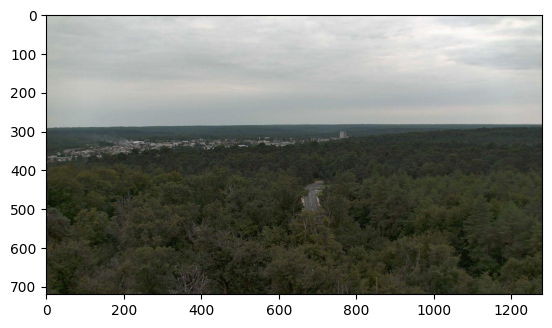

In [8]:
im = cv2.imread(img_file)
plt.imshow(im[:,:,::-1])

(1, 384, 384) float32


ex.set_num_threads() is no-op, please set net.opt.num_threads=N before net.load_param()
If you want to use single thread for only some layer, see https://github.com/Tencent/ncnn/wiki/layer-feat-mask


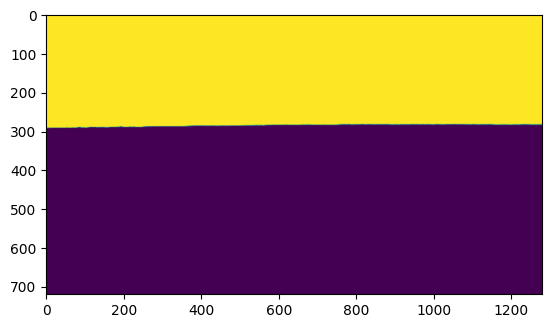

In [9]:
opencv_mask = extract_skyline(im)
plt.imshow(opencv_mask)

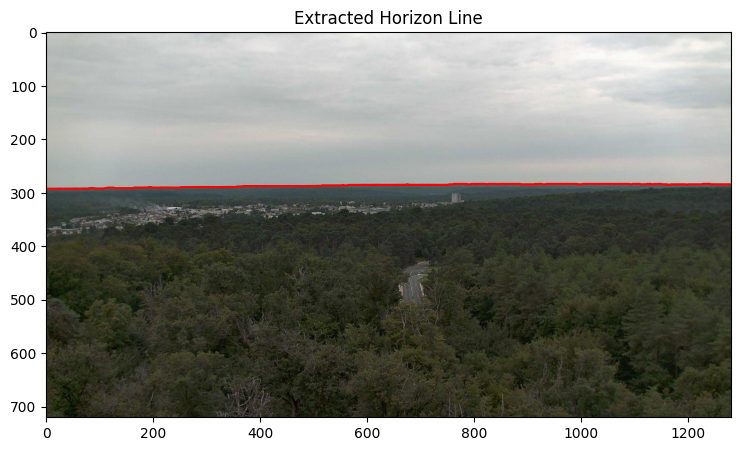

In [10]:
horizon_line_img = np.argmax(opencv_mask < 150/255, axis=0)
plt.figure(figsize=(10, 5))
plt.imshow(im[:,:,::-1], cmap='viridis')
plt.plot(horizon_line_img, color='red')
plt.title("Extracted Horizon Line")

plt.show()

In [11]:
site_data = sites_data[sites_data["name"]==site]
site_data

,name,lat,lon,elevation,fov_x,fov_y
5,croix-augas,48.426746,2.710876,150,54,44


In [12]:
lat = float(site_data["lat"])
lon = float(site_data["lon"])
pitch, roll = 0, 0
elevation = int(site_data["elevation"])  # Elevation + tour size 
fov_x = int(site_data["fov_x"])
fov_y = int(site_data["fov_y"])
lat, lon, elevation

(48.42674613, 2.71087591, 150)

In [13]:
azimuth = 217
pitch = 0

In [14]:
bbox = compute_dem_bbox_from_point(lat, lon)
download_dem_eio(bbox)
reproject_and_save_dem("srtm_dem.tif", "srtm_dem_l93.tif")


Running: eio --product SRTM1 clip --bounds 2.261718267940239 48.1278210863507 3.1600335520597604 48.72392323200784 --output srtm_dem.tif
✅ DEM downloaded: srtm_dem.tif
✅ Reprojected DEM saved to srtm_dem_l93.tif


In [15]:
# === Load Camera Metadata ===
cam_name = f"{site}-{azimuth}"
cam_info = pd.Series({
    "login": cam_name,
    "lat": lat,
    "lon": lon,
    "geometry": Point(lon, lat),
    "azimuth" : float(azimuth),
    "pitch" : pitch,
    "elevation" : elevation,
    "roll" : roll
})

# Create a GeoSeries with correct CRS
gdf_cams = gpd.GeoDataFrame([cam_info], geometry="geometry", crs="EPSG:4326")


# === Load Test Image ===
test_img = Image.open(img_file)
test_img_res = test_img.size



In [17]:
# === Prepare DEM ===
dem_data = rioxarray.open_rasterio("srtm_dem_l93.tif", masked=True).squeeze()
if dem_data.rio.crs != "EPSG:2154":
    dem_data = dem_data.rio.reproject("EPSG:2154")
dem_path = "dem_l93.tif"
dem_data.rio.to_raster(dem_path)

dem = RasterioDEM(dem_path, crs="EPSG:2154")
dem.build_pcd(sample_step=2)
dem.build_mesh()

print("[DEBUG] Mesh bounds:", dem.mesh.bounds)
print("[DEBUG] Mesh extents (X/Y):", dem.mesh.extents[:2])
print("[DEBUG] Mesh centroid:", dem.mesh.centroid)


mesh.vertices.shape = (1903008, 3)
mesh.vertices[:5] = [[ 645070.58856436 6847341.70941068   -9999.        ]
 [ 645118.94887701 6847341.70941068   -9999.        ]
 [ 645167.30918966 6847341.70941068   -9999.        ]
 [ 645215.66950231 6847341.70941068   -9999.        ]
 [ 645264.02981496 6847341.70941068   -9999.        ]]
[DEBUG] Mesh bounds: [[ 6.45070589e+05  6.78084628e+06 -9.99900000e+03]
 [ 7.11904541e+05  6.84734171e+06  2.06000000e+02]]
[DEBUG] Mesh extents (X/Y): [66833.95208279 66495.42989424]
[DEBUG] Mesh centroid: [ 6.77580136e+05  6.81590406e+06 -1.65760763e+03]


In [97]:
# === Create Camera Model ===
cam_model = CTCameraModel(
        test_img_res,
        fov_x, fov_y,
        300,
        -4,
        cam_info.roll,
        cam_info.lat,
        cam_info.lon,
        cam_info.elevation+100,
        crs="EPSG:2154"
    )
# Manual overrides


geocam = GeoRefCam(cam_model, dem)


In [98]:
cam_info

login                       croix-augas-217
lat                               48.426746
lon                                2.710876
geometry     POINT (2.71087591 48.42674613)
azimuth                               217.0
pitch                                     0
elevation                               150
roll                                      0
dtype: object

In [99]:


cam_dirvec = get_direction_vector(geocam.camera_model.yaw_deg, geocam.camera_model.pitch_deg)

# Reproject camera location if needed
if geocam.camera_model.cam_loc[3] != geocam.dem.crs:
    cam_loc = geocam.project_points_from_cam_to_dem_crs(
        np.array([geocam.camera_model.cam_loc[:3]])
    )[0]
else:
    cam_loc = geocam.camera_model.cam_loc[:3]


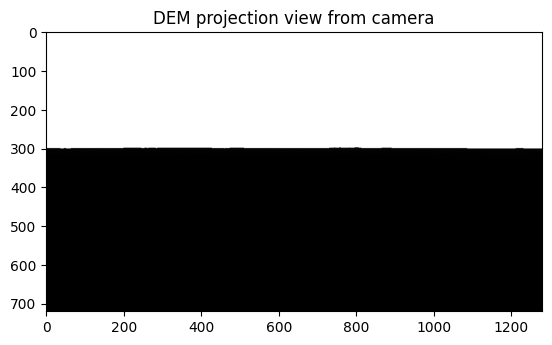

In [100]:
# Setup PyVista camera
pv_camera = pv.Camera()
pv_camera.position = cam_loc
pv_camera.focal_point = cam_loc + cam_dirvec
pv_camera.view_angle = geocam.camera_model.view_y_deg
pv_camera.clipping_range = (30, 1e5)
pv_camera.up = (0, 0, 1)

# Create plot
plotter = pv.Plotter(off_screen=True, window_size=test_img.size)
plotter.camera = pv_camera

plot_pv_meshgrid = pv.StructuredGrid(*[geocam.dem.pcd[:, :, i] for i in range(3)])
plot_pv_meshgrid["alt"] = geocam.dem.pcd[:, :, 2].ravel(order="F")
plotter.add_mesh(plot_pv_meshgrid, lighting=False)
plotter.remove_scalar_bar()

plotter.screenshot()
dem_depth = -1 * plotter.get_image_depth()
dem_depth = np.nan_to_num(dem_depth, nan=1e6)


# === Display Result ===
plt.imshow(dem_depth, cmap='gray')
plt.title("DEM projection view from camera")

plt.show()


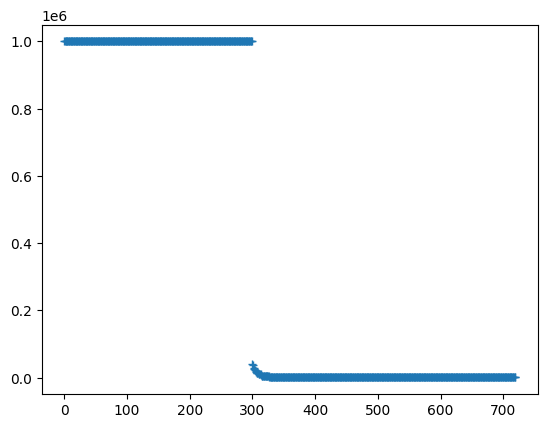

In [101]:
plt.plot(dem_depth[:,750], "+")

In [102]:
arr = dem_depth.copy()
mask = arr==arr.max()

arr[mask] = 0

min_val = np.nanpercentile(arr[~mask], 5)
max_val = np.nanpercentile(arr[~mask], 95)

min_val, max_val

(220.82722778320314, 4745.634863281247)

In [103]:
norm = (arr - min_val) / (max_val - min_val)
norm = np.clip(norm, 0, 1)

result = np.zeros_like(arr, dtype="float32")
result[~mask] = norm[~mask] * 255

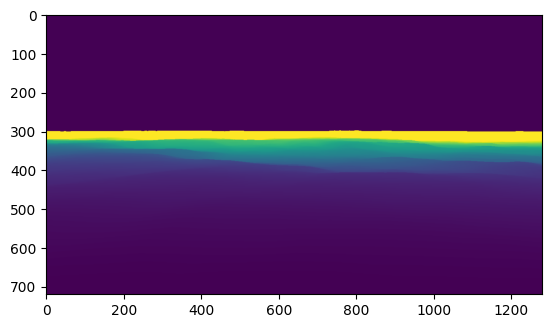

In [104]:
plt.imshow(result)

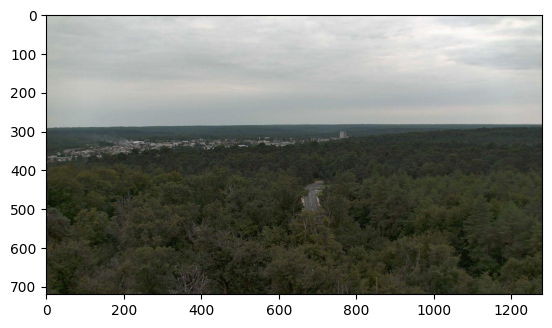

In [71]:
plt.imshow(im[:,:,::-1], cmap='viridis')

In [72]:
fov_x

54

In [33]:
normalized = safe_normalize(dem_depth.copy(), th_min=1, th_max=99, scale=255.0).astype(np.uint8)
cv2.imwrite("dem.jpg", 255-normalized)

True

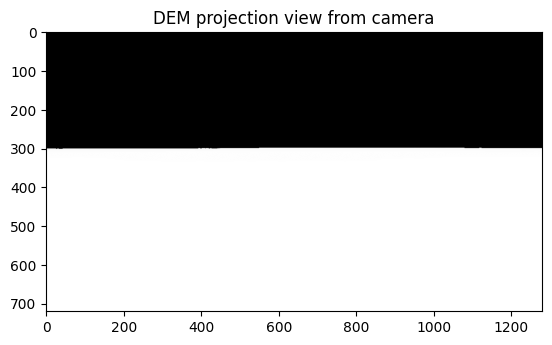

In [34]:
plt.imshow(255-normalized, cmap='gray')
plt.title("DEM projection view from camera")
plt.show()

In [27]:
mm = dem_depth.max()

dem_depth = dem_depth/mm
dem_depth

pyvista_ndarray([[1.0000000e+00, 1.0000000e+00, 1.0000000e+00, ...,
                  1.0000000e+00, 1.0000000e+00, 1.0000000e+00],
                 [1.0000000e+00, 1.0000000e+00, 1.0000000e+00, ...,
                  1.0000000e+00, 1.0000000e+00, 1.0000000e+00],
                 [1.0000000e+00, 1.0000000e+00, 1.0000000e+00, ...,
                  1.0000000e+00, 1.0000000e+00, 1.0000000e+00],
                 ...,
                 [2.1252854e-04, 2.1250709e-04, 2.1248571e-04, ...,
                  2.1798846e-04, 2.1799335e-04, 2.1799820e-04],
                 [2.1188465e-04, 2.1186337e-04, 2.1184207e-04, ...,
                  2.1739017e-04, 2.1739502e-04, 2.1739988e-04],
                 [2.1124464e-04, 2.1122349e-04, 2.1120235e-04, ...,
                  2.1679519e-04, 2.1679999e-04, 2.1680479e-04]],
                dtype=float32)

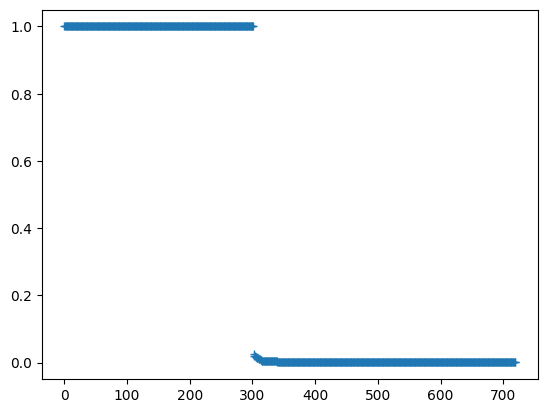

In [28]:
plt.plot(dem_depth[:,6], "+")

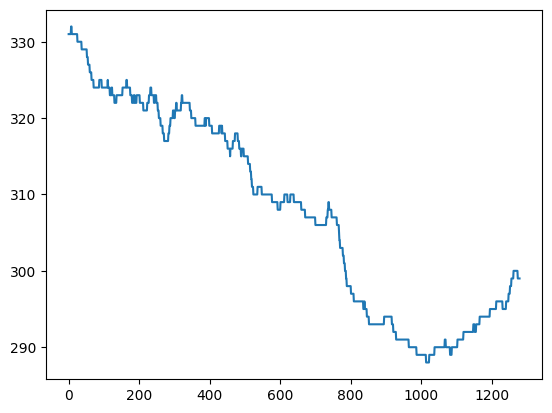

In [89]:
horizon_line = np.argmax(dem_depth <0.5, axis=0)
plt.plot(horizon_line)

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import cv2

# === INPUT ===
# Replace these with your actual data
# horizon_line_img: (1280,) real curve from image
# horizon_line_sim: (1280,) simulated curve

# For demo purposes, fake curves:
# horizon_line_img = np.load('real_curve.npy')
# horizon_line_sim = np.load('sim_curve.npy')

# === 1. Smooth curves ===
sigma = 2
smooth_img = gaussian_filter1d(horizon_line_img, sigma=sigma)
smooth_sim = gaussian_filter1d(horizon_line, sigma=sigma)

# === 2. Detect peaks and valleys ===
prominence = 5
peaks_img, _ = find_peaks(smooth_img, prominence=prominence)
valleys_img, _ = find_peaks(-smooth_img, prominence=prominence)
landmarks_img = np.sort(np.concatenate([peaks_img, valleys_img]))
xy_img = np.column_stack([landmarks_img, smooth_img[landmarks_img]])

peaks_sim, _ = find_peaks(smooth_sim, prominence=prominence)
valleys_sim, _ = find_peaks(-smooth_sim, prominence=prominence)
landmarks_sim = np.sort(np.concatenate([peaks_sim, valleys_sim]))
xy_sim = np.column_stack([landmarks_sim, smooth_sim[landmarks_sim]])

# === 3. Match landmarks (nearest y match) ===
from scipy.spatial.distance import cdist
dist = cdist(xy_img[:,1][:,None], xy_sim[:,1][:,None])
best_match = np.argmin(dist, axis=1)

# Only keep valid matches (some might be duplicates or mismatched)
unique_matches = np.unique(best_match, return_index=True)[1]
src_pts = xy_sim[best_match[unique_matches]]
dst_pts = xy_img[unique_matches]

# Extra safety check
assert src_pts.shape == dst_pts.shape, "Mismatched point sets for transform"


# === 4. Estimate rigid transform ===
M, _ = cv2.estimateAffinePartial2D(src_pts, dst_pts, method=cv2.RANSAC)

# === 5. Apply transform to full simulated curve ===
x = np.arange(len(horizon_line))
pts_sim = np.column_stack([x, horizon_line])
aligned_pts = (M[:, :2] @ pts_sim.T + M[:, 2:]).T
aligned_curve = aligned_pts[:,1]

# === 6. Plot results ===
plt.figure(figsize=(12, 6))
plt.plot(horizon_line_img, label='Real (image)', color='red', linewidth=2)
plt.plot(horizon_line, label='Simulated (raw)', color='blue', linestyle='--')
plt.plot(aligned_curve, label='Simulated (aligned)', color='green')

plt.scatter(landmarks_img, smooth_img[landmarks_img], color='red', s=30, label='Real landmarks')
plt.scatter(landmarks_sim, smooth_sim[landmarks_sim], color='blue', s=30, label='Sim landmarks')

plt.title('Horizon Curve Matching and Alignment')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


error: OpenCV(4.11.0) /Users/xperience/GHA-Actions-OpenCV/_work/opencv-python/opencv-python/opencv/modules/calib3d/src/ptsetreg.cpp:176: error: (-215:Assertion failed) count >= 0 && count2 == count in function 'run'


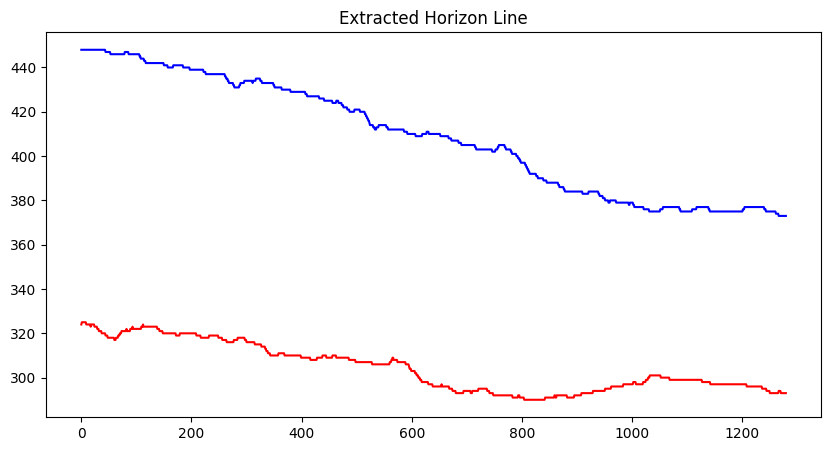

In [72]:


# Plot the result
plt.figure(figsize=(10, 5))
#plt.imshow(dem_depth, cmap='viridis')
plt.plot(horizon_line, color='red')
plt.plot(horizon_line_img, color='blue')

plt.title("Extracted Horizon Line")

plt.show()

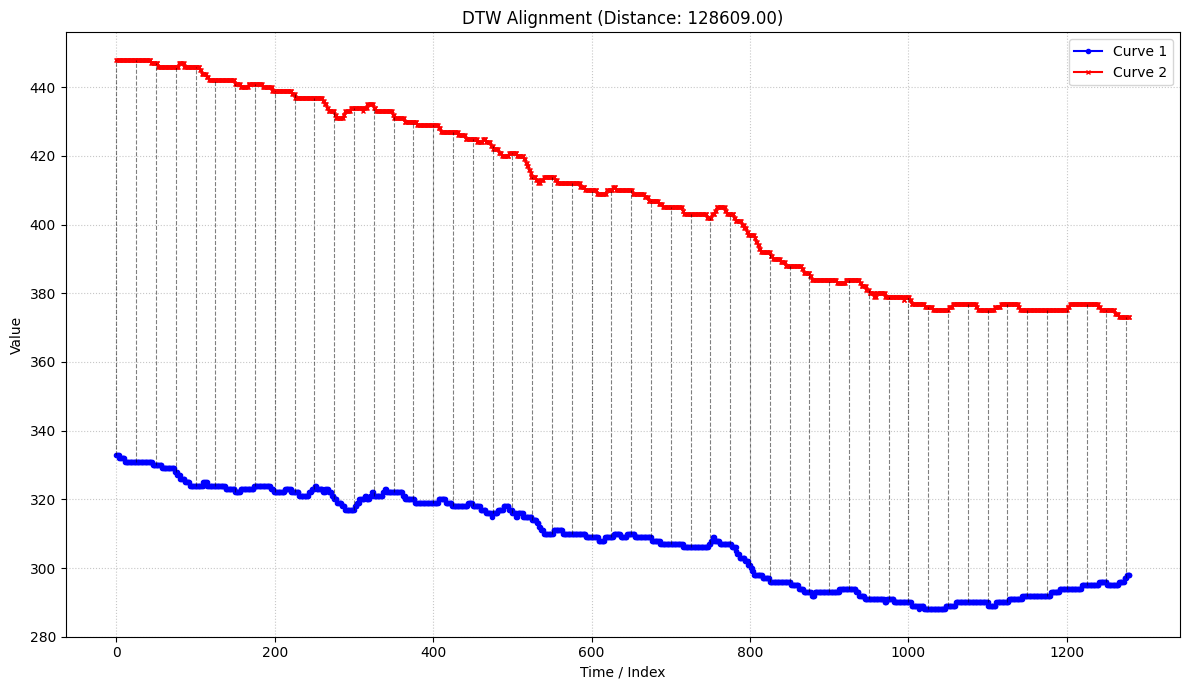

DTW Distance (Matching Score): 128609.0


In [60]:
import numpy as np
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import matplotlib.pyplot as plt

def align_curves_dtw(curve1, curve2, plot_alignment=True):
    """
    Aligns two curves using Dynamic Time Warping (DTW) and calculates a matching score.

    Args:
        curve1 (np.array): The first curve (1D array of y-values).
        curve2 (np.array): The second curve (1D array of y-values).
        plot_alignment (bool): Whether to plot the curves and their alignment.

    Returns:
        tuple: (dtw_distance, warping_path)
               dtw_distance (float): The DTW distance, serving as a matching score.
                                     Lower values indicate a better match.
               warping_path (list): A list of tuples representing the mapping
                                    between indices of curve1 and curve2.
    """
    # The 'radius' parameter in fastdtw controls the window size for the Sakoe-Chiba band.
    # A larger radius allows for more flexibility in warping but increases computation time.
    # Start with a reasonable radius, e.g., 10-20% of the average sequence length, or adjust as needed.
    radius = int(max(len(curve1), len(curve2)) * 0.15) # Example: 15% of max length
    if radius == 0: # Ensure radius is at least 1 if sequences are very short
        radius = 1

    # fastdtw requires inputs to be 2D arrays where each row is a point and each column is a dimension.
    # For 1D time series, we reshape them to (n_samples, 1).
    c1_reshaped = curve1.reshape(-1, 1)
    c2_reshaped = curve2.reshape(-1, 1)

    dtw_distance, warping_path = fastdtw(c1_reshaped, c2_reshaped, radius=radius, dist=euclidean)

    if plot_alignment:
        # Create x-axes for plotting
        x1 = np.arange(len(curve1))
        x2 = np.arange(len(curve2))

        fig, ax = plt.subplots(figsize=(12, 7))

        # Plot the two curves
        ax.plot(x1, curve1, 'b-', label='Curve 1', marker='o', markersize=3)
        ax.plot(x2, curve2, 'r-', label='Curve 2', marker='x', markersize=3)

        # Plot the warping path connections
        # For clarity, only plot a subset of connections if the path is too dense
        num_connections_to_plot = 50
        step = max(1, len(warping_path) // num_connections_to_plot)

        for i in range(0, len(warping_path), step):
            idx1, idx2 = warping_path[i]
            ax.plot([x1[idx1], x2[idx2]], [curve1[idx1], curve2[idx2]], 'k--', alpha=0.5, linewidth=0.8)

        ax.set_title(f'DTW Alignment (Distance: {dtw_distance:.2f})')
        ax.set_xlabel('Time / Index')
        ax.set_ylabel('Value')
        ax.legend()
        ax.grid(True, linestyle=':', alpha=0.7)
        plt.tight_layout()
        plt.show()

    return dtw_distance, warping_path



curve1 = horizon_line
curve2 = horizon_line_img



# --- Perform Alignment and Get Score ---
dtw_distance, path = align_curves_dtw(curve1, curve2, plot_alignment=True)

print(f"DTW Distance (Matching Score): {dtw_distance}")



In [73]:
import numpy as np
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import matplotlib.pyplot as plt
from scipy.stats import zscore

def align_curves_dtw(curve1, curve2, normalize_y=True, plot_alignment=True, plot_title_prefix=""):
    """
    Aligns two curves using Dynamic Time Warping (DTW) and calculates a matching score.
    Allows for Z-score normalization of Y-values before DTW.

    Args:
        curve1 (np.array): The first curve (1D array of y-values).
        curve2 (np.array): The second curve (1D array of y-values).
        normalize_y (bool): If True, applies Z-score normalization to each curve's
                              Y-values before performing DTW. This makes the comparison
                              more invariant to shifts and scaling in the Y-axis.
        plot_alignment (bool): Whether to plot the curves and their alignment.
        plot_title_prefix (str): A prefix for the plot title.

    Returns:
        tuple: (dtw_distance, warping_path, curve1_processed, curve2_processed)
               dtw_distance (float): The DTW distance.
               warping_path (list): The warping path.
               curve1_processed (np.array): Curve 1 after any processing (e.g., normalization).
               curve2_processed (np.array): Curve 2 after any processing.
    """
    curve1_processed = np.copy(curve1)
    curve2_processed = np.copy(curve2)

    if normalize_y:
        # Apply Z-score normalization to each curve independently
        # Ensure there's variance to avoid division by zero if a curve is flat
        if np.std(curve1_processed) > 1e-6: # Check for non-zero standard deviation
            curve1_processed = zscore(curve1_processed)
        else: # If curve is flat, zscore would result in NaNs or error. Center it at 0.
            curve1_processed = curve1_processed - np.mean(curve1_processed)

        if np.std(curve2_processed) > 1e-6:
            curve2_processed = zscore(curve2_processed)
        else:
            curve2_processed = curve2_processed - np.mean(curve2_processed)
        
        # If after normalization one of the curves became all NaNs (e.g. input was single point)
        # revert to original curve for that one to avoid error in fastdtw
        if np.isnan(curve1_processed).all(): curve1_processed = np.copy(curve1)
        if np.isnan(curve2_processed).all(): curve2_processed = np.copy(curve2)


    # The 'radius' parameter in fastdtw controls the window size for the Sakoe-Chiba band.
    radius = int(max(len(curve1_processed), len(curve2_processed)) * 0.15)
    if radius == 0: radius = 1


    c1_reshaped = curve1_processed.reshape(-1, 1)
    c2_reshaped = curve2_processed.reshape(-1, 1)

    dtw_distance, warping_path = fastdtw(c1_reshaped, c2_reshaped, radius=radius, dist=euclidean)

    if plot_alignment:
        x1 = np.arange(len(curve1_processed))
        x2 = np.arange(len(curve2_processed))

        fig, ax = plt.subplots(figsize=(12, 7))

        # Plot the (potentially normalized) curves
        ax.plot(x1, curve1_processed, 'b-', label='Curve 1 (Processed)', marker='o', markersize=3)
        ax.plot(x2, curve2_processed, 'r-', label='Curve 2 (Processed)', marker='x', markersize=3)

        num_connections_to_plot = 50
        step = max(1, len(warping_path) // num_connections_to_plot)

        for i in range(0, len(warping_path), step):
            idx1, idx2 = warping_path[i]
            # Ensure indices are within bounds (can happen if curves are very different lengths
            # and normalization leads to extreme warping paths with fastdtw's radius)
            if idx1 < len(x1) and idx2 < len(x2):
                 ax.plot([x1[idx1], x2[idx2]], [curve1_processed[idx1], curve2_processed[idx2]], 'k--', alpha=0.5, linewidth=0.8)


        title_norm_status = "(Normalized)" if normalize_y else "(Original Scale)"
        ax.set_title(f'{plot_title_prefix}DTW Alignment {title_norm_status} (Distance: {dtw_distance:.2f})')
        ax.set_xlabel('Time / Index')
        ax.set_ylabel('Value (Processed)' if normalize_y else 'Value (Original)')
        ax.legend()
        ax.grid(True, linestyle=':', alpha=0.7)
        plt.tight_layout()
        plt.show()

    return dtw_distance, warping_path, curve1_processed, curve2_processed

--- DTW on Original Data ---


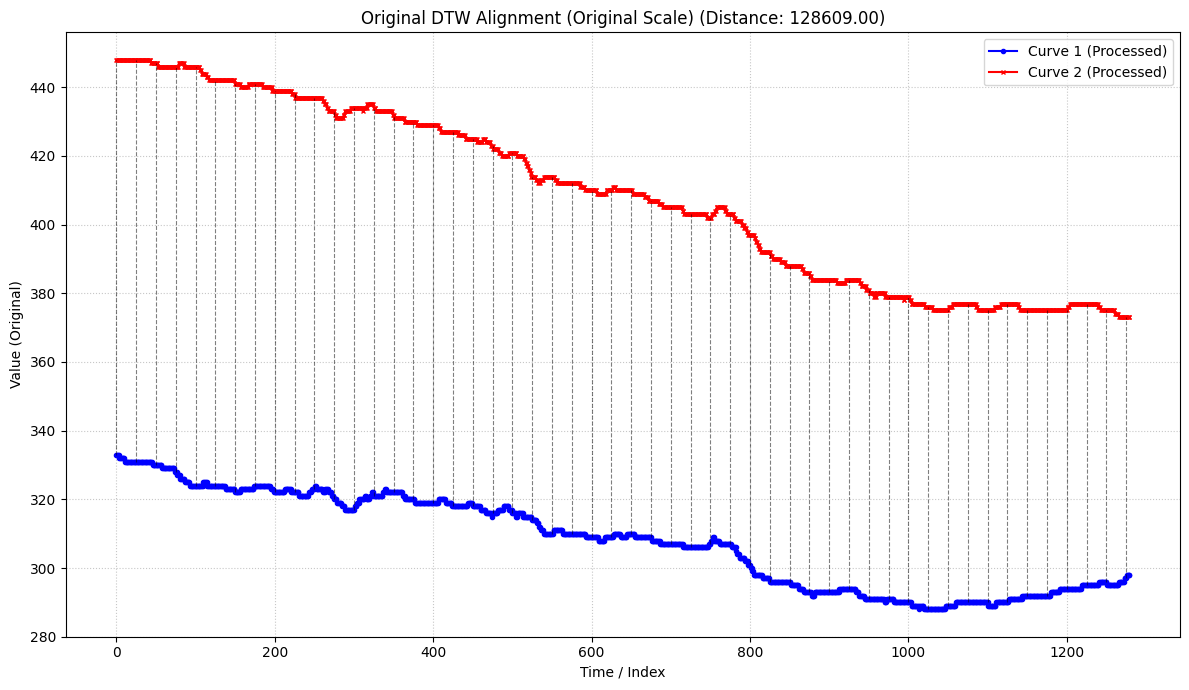

DTW Distance (Original Data): 128609.00


In [74]:
# --- Scenario 1: DTW on Original Data (expect large distance) ---
print("--- DTW on Original Data ---")
dtw_dist_orig, path_orig, _, _ = align_curves_dtw(
    curve1, 
    curve2, 
    normalize_y=False, 
    plot_alignment=True,
    plot_title_prefix="Original "
)
print(f"DTW Distance (Original Data): {dtw_dist_orig:.2f}")

In [78]:
curve1_raw = horizon_line_img
curve2_raw = horizon_line


--- DTW on Normalized Data (Z-score) ---


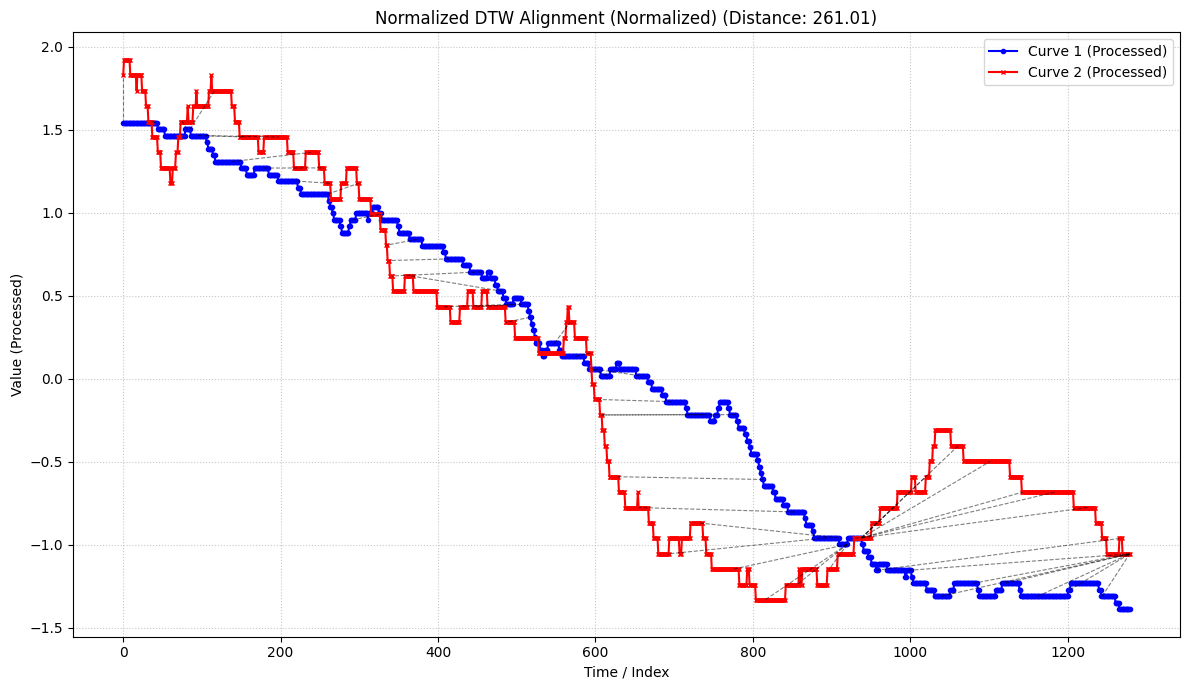

DTW Distance (Normalized Data): 261.01


In [79]:
# --- Scenario 2: DTW on Normalized Data (expect smaller distance) ---
print("\n--- DTW on Normalized Data (Z-score) ---")
dtw_dist_norm, path_norm, c1_norm, c2_norm = align_curves_dtw(
    curve1_raw, 
    curve2_raw, 
    normalize_y=True, 
    plot_alignment=True,
    plot_title_prefix="Normalized "
)
print(f"DTW Distance (Normalized Data): {dtw_dist_norm:.2f}")




In [46]:
blue_curve = horizon_line_img.copy()
red_curve = horizon_line.copy()

In [47]:
offset = blue_curve.mean() - red_curve.mean()
aligned_red_curve = red_curve + offset


In [48]:
from scipy.signal import correlate
import numpy as np

# Assuming both curves are 1D numpy arrays of the same length
correlation = correlate(blue_curve, red_curve, mode='same')
best_shift = np.argmax(correlation) - len(red_curve) // 2

aligned_red_curve = np.roll(red_curve, shift=best_shift)


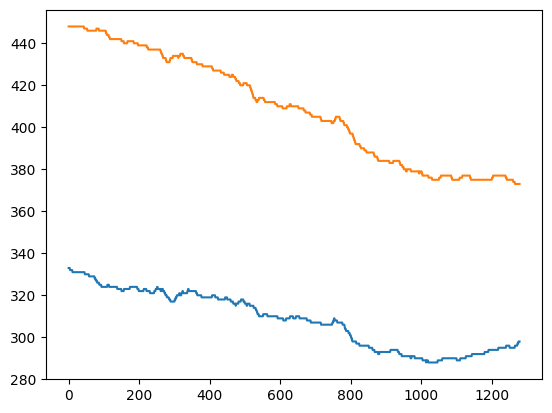

In [56]:
plt.plot(aligned_red_curve)
plt.plot(blue_curve)

In [57]:
from dtw import dtw
import numpy as np

# Ensure your inputs are numpy arrays
red_curve = np.array(red_curve).reshape(-1, 1)
blue_curve = np.array(blue_curve).reshape(-1, 1)

# Use Euclidean distance as the distance function
manhattan_distance = lambda x, y: np.abs(x - y)

# Run DTW
alignment = dtw(red_curve, blue_curve, dist=manhattan_distance)

# Get aligned path
path = alignment.index1, alignment.index2


AttributeError: 'tuple' object has no attribute 'index1'

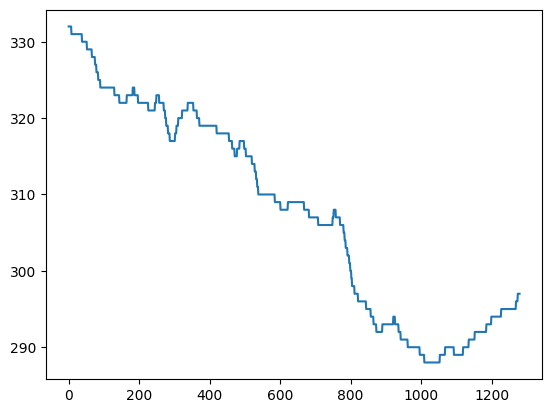

In [38]:
from scipy.ndimage import gaussian_filter1d

smoothed_curve = gaussian_filter1d(horizon_line, sigma=2)
plt.plot(smoothed_curve)

In [39]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(smoothed_curve, prominence=5)
valleys, _ = find_peaks(-smoothed_curve, prominence=5)


In [40]:
landmarks_x = np.sort(np.concatenate([peaks, valleys]))
landmarks_y = smoothed_curve[landmarks_x]


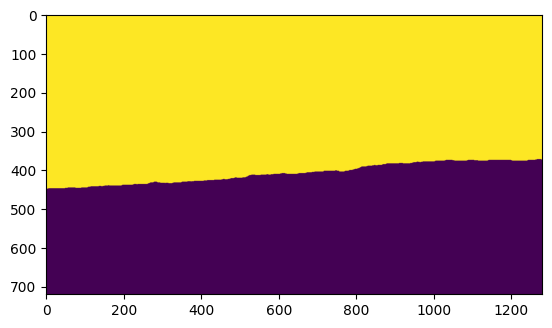

In [29]:
src_mask = (opencv_mask > 0.5).astype(np.uint8)
plt.imshow(src_mask)

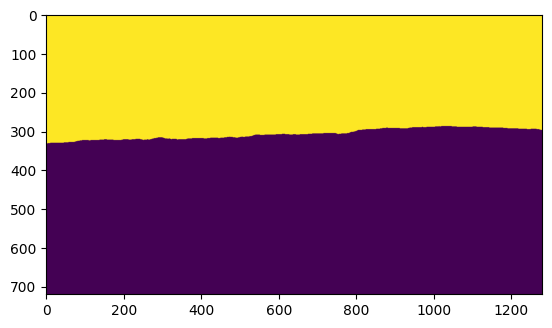

In [30]:
dst_mask = (dem_depth > 0.5).astype(np.uint8)
plt.imshow(dst_mask)

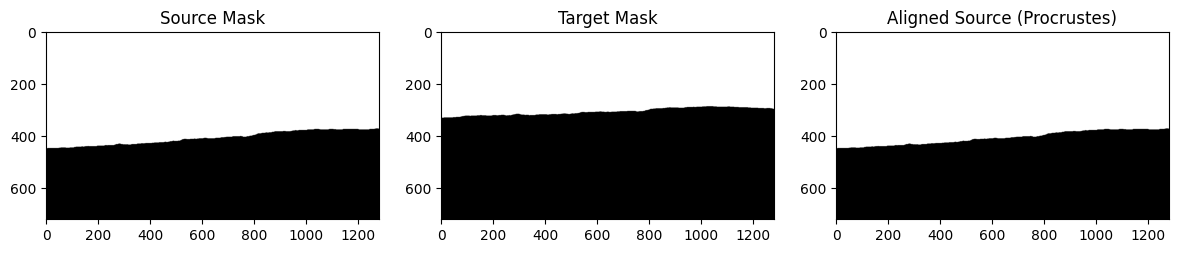

In [37]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.spatial import procrustes

def load_mask(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    return (img > 128).astype(np.uint8)

def extract_top_edge(mask):
    """Extract 1D top edge (y values of first 1s along columns)"""
    h, w = mask.shape
    edge = np.full(w, h - 1)
    for x in range(w):
        col = mask[:, x]
        top = np.argmax(col > 0)
        if col[top] == 0:
            edge[x] = h - 1
        else:
            edge[x] = top
    return np.column_stack([np.arange(w), edge]).astype(np.float32)

def estimate_procrustes_transform(src_pts, dst_pts):
    """Estimate rigid transform (rotation + translation) via Procrustes (no scale)"""
    src_mean = src_pts.mean(axis=0)
    dst_mean = dst_pts.mean(axis=0)
    
    src_centered = src_pts - src_mean
    dst_centered = dst_pts - dst_mean

    U, _, Vt = np.linalg.svd(dst_centered.T @ src_centered)
    R = U @ Vt
    t = dst_mean - src_mean @ R.T

    M = np.hstack([R, t.reshape(2, 1)])  # 2x3 affine matrix
    return M

def warp_mask(mask, M, shape):
    return cv2.warpAffine(mask, M, (shape[1], shape[0]), flags=cv2.INTER_NEAREST)

# Load

# Extract top edge points
src_pts = extract_top_edge(src_mask)
dst_pts = extract_top_edge(dst_mask)

# Optional: subsample
N = min(len(src_pts), len(dst_pts), 1000)
src_pts = src_pts[:N]
dst_pts = dst_pts[:N]

# Estimate rigid transform
M = estimate_procrustes_transform(src_pts, dst_pts)

# Warp
aligned = warp_mask(src_mask, M, dst_mask.shape)

# Visualize
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(src_mask, cmap='gray')
plt.title("Source Mask")

plt.subplot(1, 3, 2)
plt.imshow(dst_mask, cmap='gray')
plt.title("Target Mask")

plt.subplot(1, 3, 3)
plt.imshow(aligned, cmap='gray')
plt.title("Aligned Source (Procrustes)")
plt.tight_layout()
plt.show()


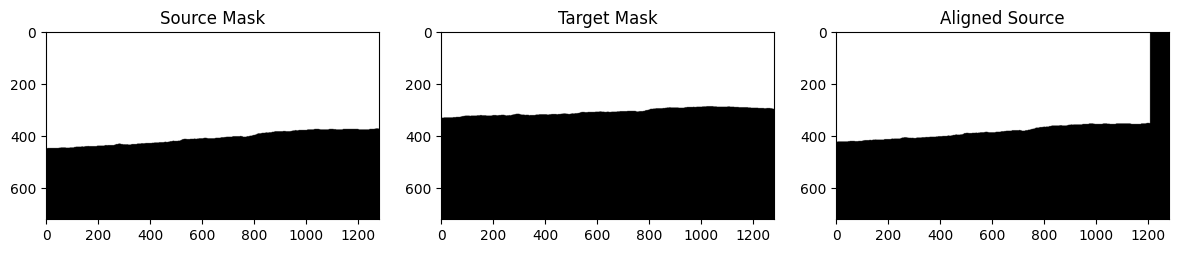

In [36]:

# === Estimate transform ===
M = estimate_rigid_transform_from_edges(src_mask, dst_mask)

# === Apply warp ===
aligned_src = warp_mask(src_mask, M, dst_mask.shape)

# === Plot ===
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(src_mask, cmap='gray')
plt.title("Source Mask")

plt.subplot(1, 3, 2)
plt.imshow(dst_mask, cmap='gray')
plt.title("Target Mask")

plt.subplot(1, 3, 3)
plt.imshow(aligned_src, cmap='gray')
plt.title("Aligned Source")
plt.tight_layout()
plt.show()

In [140]:
dtw.distance(horizon_line, horizon_line_img)

3704.6373641694

In [141]:
dtw.distance(horizon_line, horizon_line_img)

3704.6373641694

In [145]:
def get_dem_proj(dem, test_img, test_img_res, cam_info, azimuth, fov_x, fov_y):
    plotter = pv.Plotter(off_screen=True, window_size=test_img.size)

    # Create the mesh once
    plot_pv_meshgrid = pv.StructuredGrid(*[dem.pcd[:, :, i] for i in range(3)])
    plot_pv_meshgrid["alt"] = dem.pcd[:, :, 2].ravel(order="F")
    plotter.add_mesh(plot_pv_meshgrid, lighting=False)
    plotter.remove_scalar_bar()
    cam_model = CTCameraModel(
        test_img_res,
        fov_x, fov_y,
        azimuth,
        cam_info.pitch,
        cam_info.roll,
        cam_info.lat,
        cam_info.lon,
        cam_info.elevation,
        crs="EPSG:2154"
    )

    geocam = GeoRefCam(cam_model, dem)
    cam_dirvec = get_direction_vector(geocam.camera_model.yaw_deg, geocam.camera_model.pitch_deg)

    if geocam.camera_model.cam_loc[3] != geocam.dem.crs:
        cam_loc = geocam.project_points_from_cam_to_dem_crs(
            np.array([geocam.camera_model.cam_loc[:3]])
        )[0]
    else:
        cam_loc = geocam.camera_model.cam_loc[:3]

    # Update camera
    pv_camera = pv.Camera()
    pv_camera.position = cam_loc
    pv_camera.focal_point = cam_loc + cam_dirvec
    pv_camera.view_angle = geocam.camera_model.view_y_deg
    pv_camera.clipping_range = (30, 1e5)
    pv_camera.up = (0, 0, 1)
    plotter.camera = pv_camera

    # Render & get depth
    plotter.screenshot()
    dem_depth =  -1 * plotter.get_image_depth()
    dem_depth = np.nan_to_num(dem_depth, nan=1e6) 
    mm = dem_depth.max()

    return    dem_depth/mm

  0%|          | 0/36 [00:00<?, ?it/s]

1 3475.397818955407


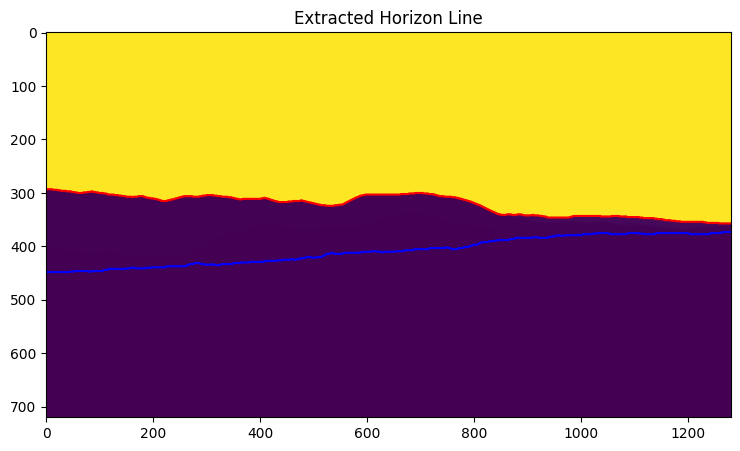

  3%|▎         | 1/36 [00:02<01:31,  2.61s/it]

11 3316.862975764902


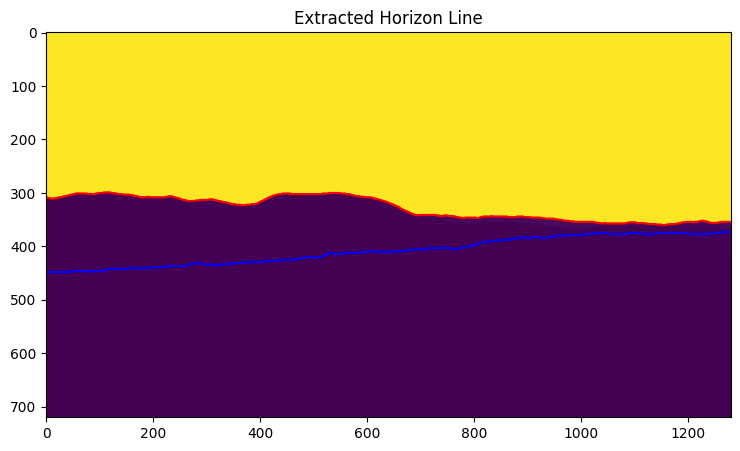

  6%|▌         | 2/36 [00:05<01:28,  2.59s/it]

21 3159.614533451826


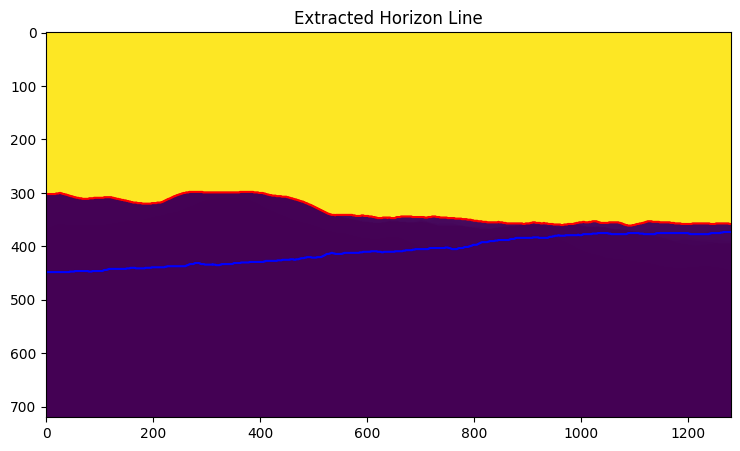

  8%|▊         | 3/36 [00:07<01:25,  2.59s/it]

31 3030.7583209487357


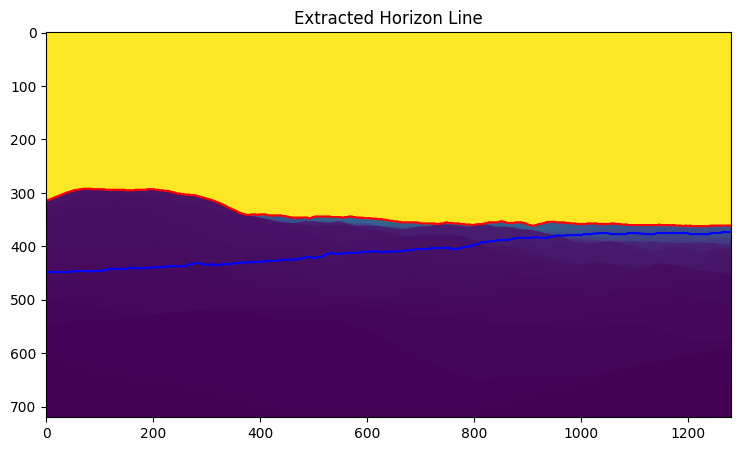

 11%|█         | 4/36 [00:10<01:23,  2.60s/it]

41 2648.9265750488444


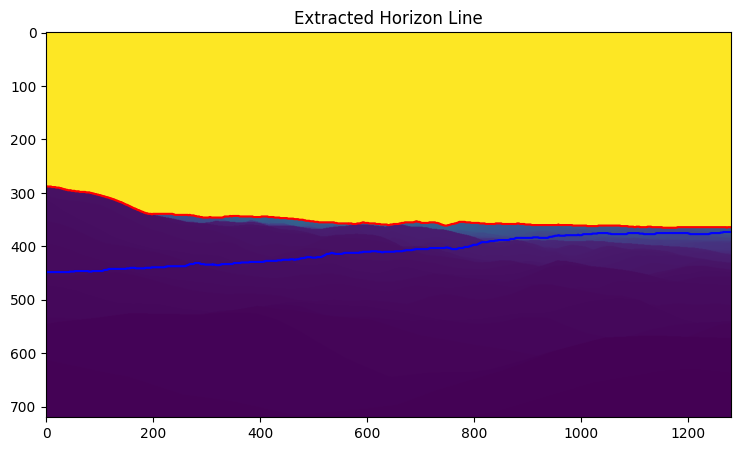

 14%|█▍        | 5/36 [00:12<01:20,  2.59s/it]

51 2224.9919100976526


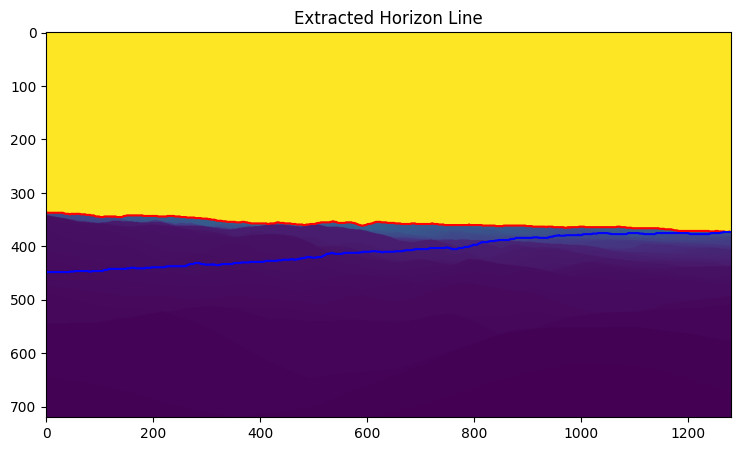

 17%|█▋        | 6/36 [00:15<01:17,  2.58s/it]

61 2083.2445847763533


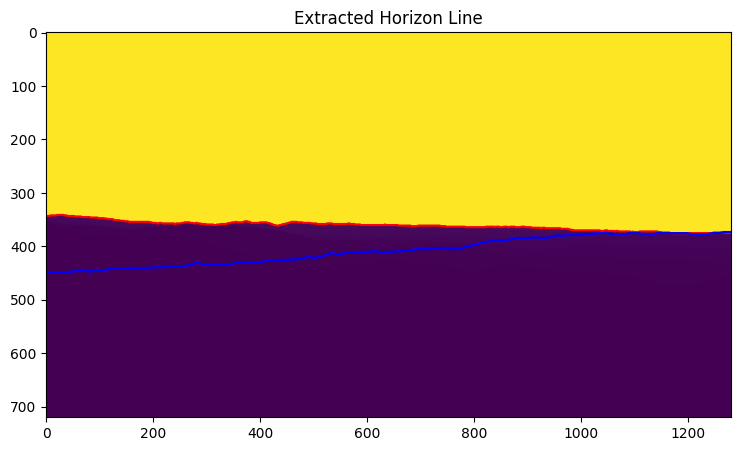

 19%|█▉        | 7/36 [00:18<01:14,  2.58s/it]

71 1961.5218581499416


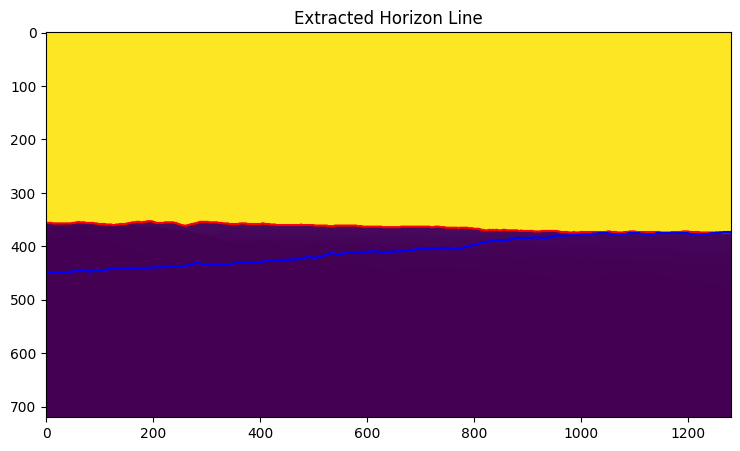

 22%|██▏       | 8/36 [00:20<01:12,  2.58s/it]

81 1898.8388557220962


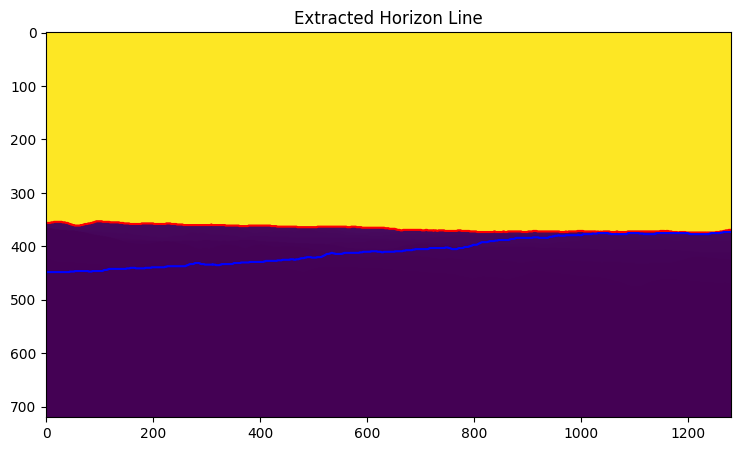

 25%|██▌       | 9/36 [00:23<01:09,  2.57s/it]

91 1807.2537176611368


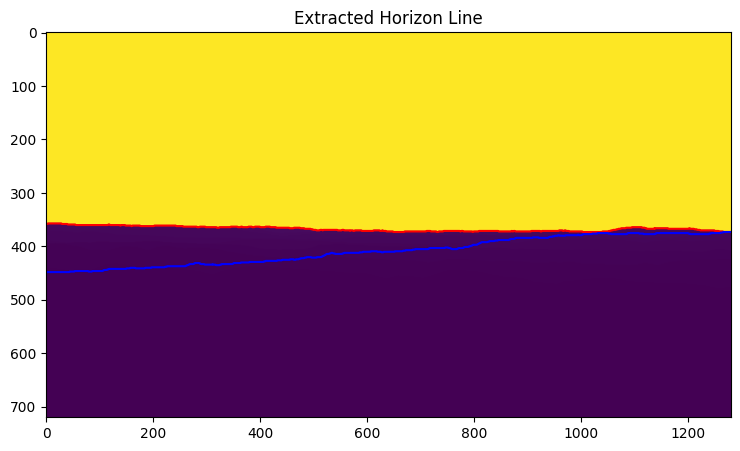

 28%|██▊       | 10/36 [00:25<01:07,  2.59s/it]

101 1714.7859924783618


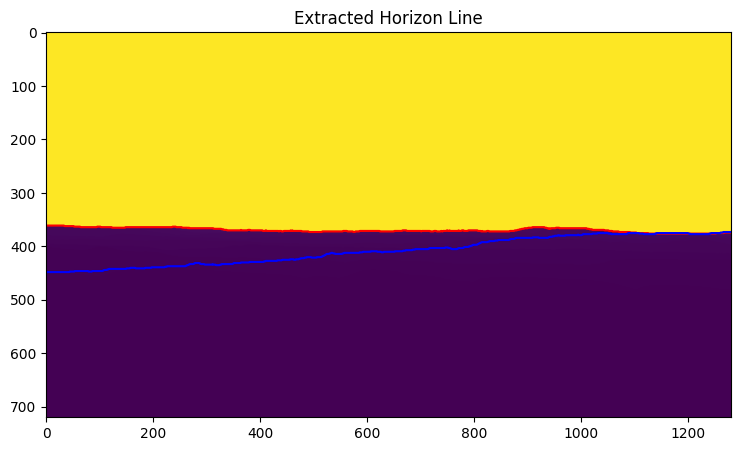

 31%|███       | 11/36 [00:28<01:04,  2.60s/it]

111 1620.871987542508


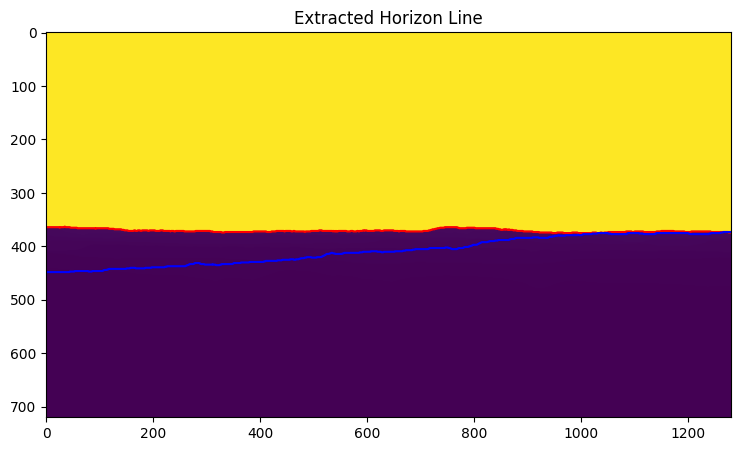

 33%|███▎      | 12/36 [00:31<01:02,  2.60s/it]Context leak detected, msgtracer returned -1


121 1528.0278138829804


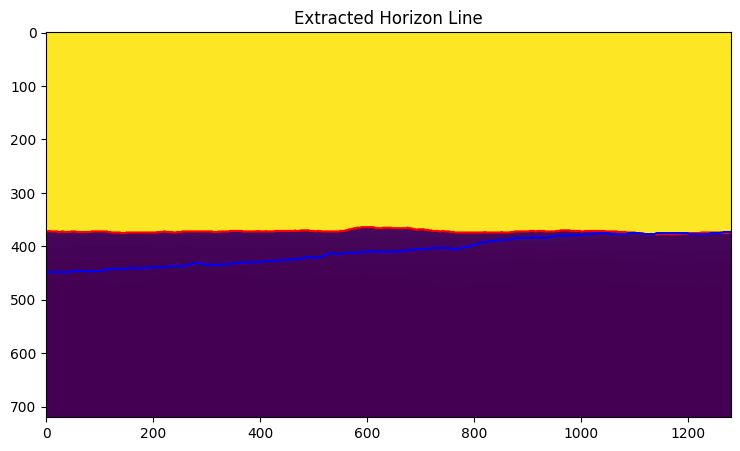

 36%|███▌      | 13/36 [00:33<00:59,  2.61s/it]

131 1511.9778437530094


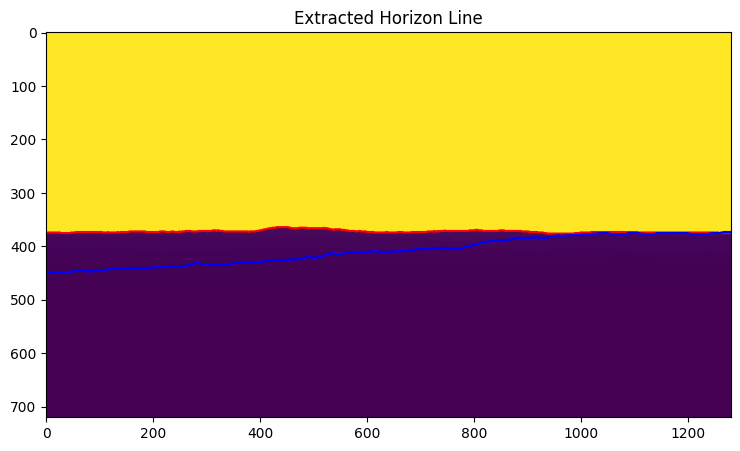

 39%|███▉      | 14/36 [00:36<00:57,  2.62s/it]

141 1514.7715999450213


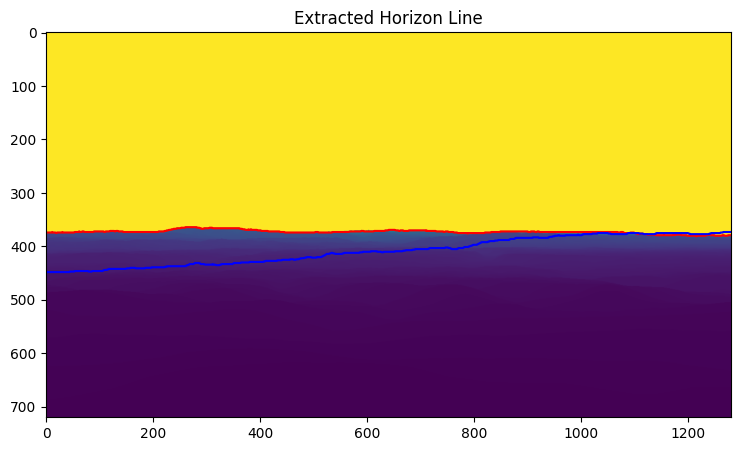

 42%|████▏     | 15/36 [00:38<00:55,  2.62s/it]2025-05-22 18:45:01.360 Python[87855:14863137] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xd17a154f0 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:01.360 Python[87855:14863137] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xd17a15530 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}


151 14644.018266855583


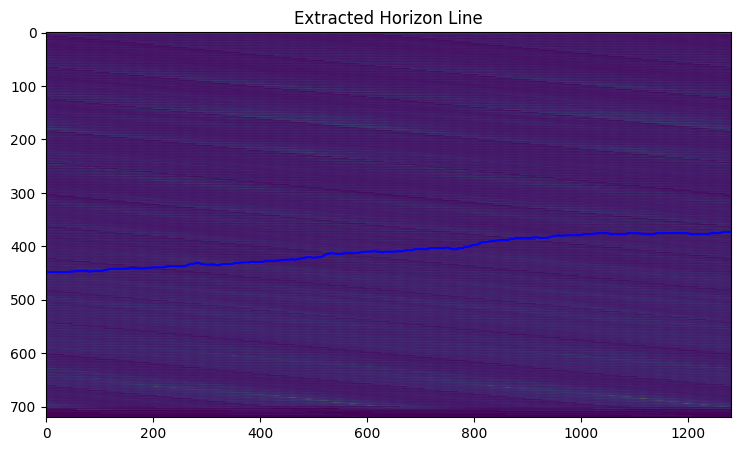

 44%|████▍     | 16/36 [00:41<00:53,  2.65s/it]2025-05-22 18:45:04.043 Python[87855:14862082] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xccffc8960 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:04.060 Python[87855:14862375] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xccffbf110 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:04.061 Python[87855:14862375] GLDRendererMetal command buffer completion error: Error Domain

161 14644.018266855583


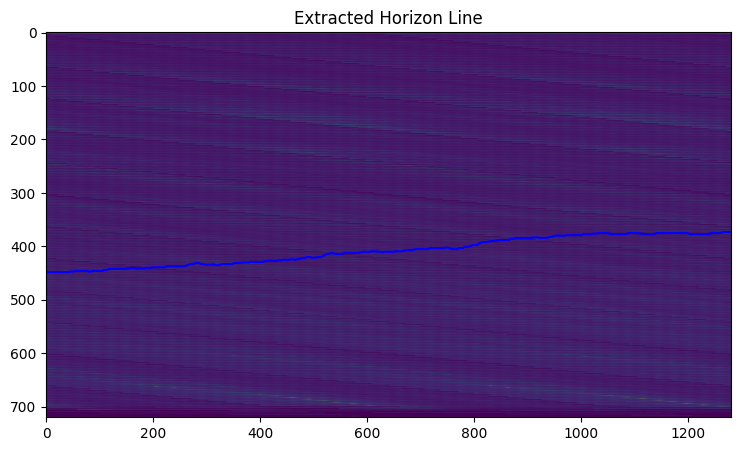

 47%|████▋     | 17/36 [00:44<00:50,  2.67s/it]2025-05-22 18:45:06.763 Python[87855:14862841] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xa1adeb500 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:06.780 Python[87855:14862372] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xd17a18340 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:06.781 Python[87855:14862372] GLDRendererMetal command buffer completion error: Error Domain

171 14644.018266855583


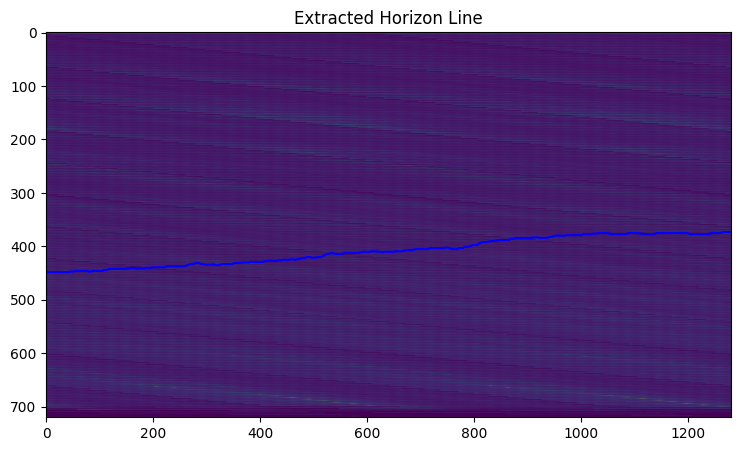

 50%|█████     | 18/36 [00:47<00:48,  2.70s/it]2025-05-22 18:45:09.548 Python[87855:14863137] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xd10b51210 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:09.570 Python[87855:14863139] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xc4fd45220 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:09.571 Python[87855:14863139] GLDRendererMetal command buffer completion error: Error Domain

181 14644.018266855583


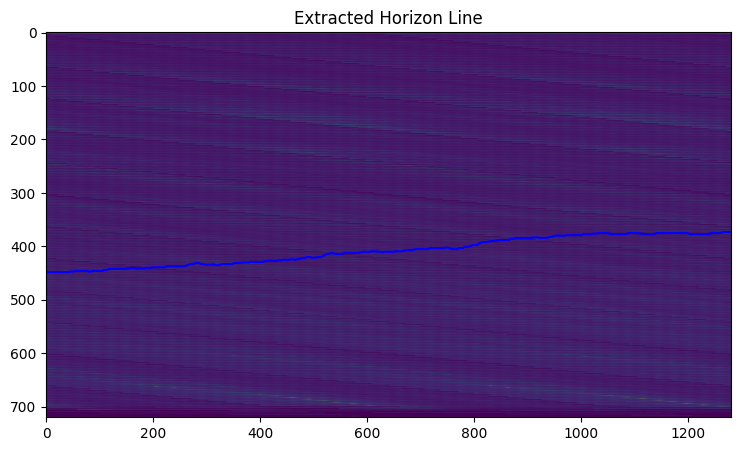

 53%|█████▎    | 19/36 [00:49<00:46,  2.72s/it]2025-05-22 18:45:12.292 Python[87855:14863139] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xc4fd48ac0 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:12.309 Python[87855:14863140] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xc4fd4ce80 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:12.310 Python[87855:14863140] GLDRendererMetal command buffer completion error: Error Domain

191 14644.018266855583


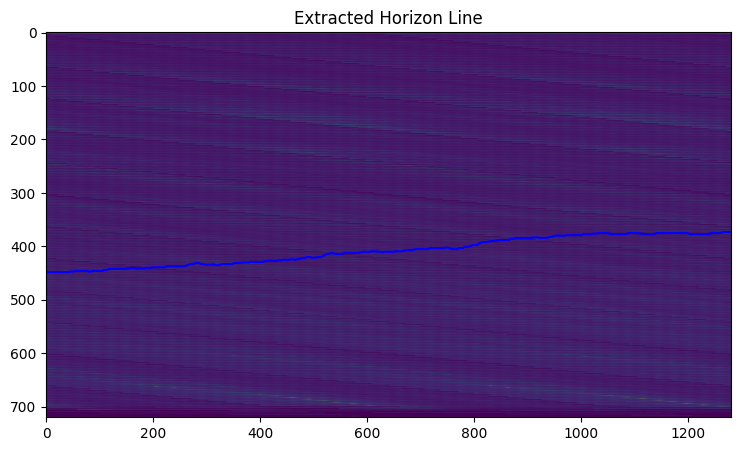

 56%|█████▌    | 20/36 [00:52<00:43,  2.72s/it]2025-05-22 18:45:15.034 Python[87855:14862082] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xc9d981da0 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:15.052 Python[87855:14862372] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xa1adeb840 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:15.052 Python[87855:14862372] GLDRendererMetal command buffer completion error: Error Domain

201 14644.018266855583


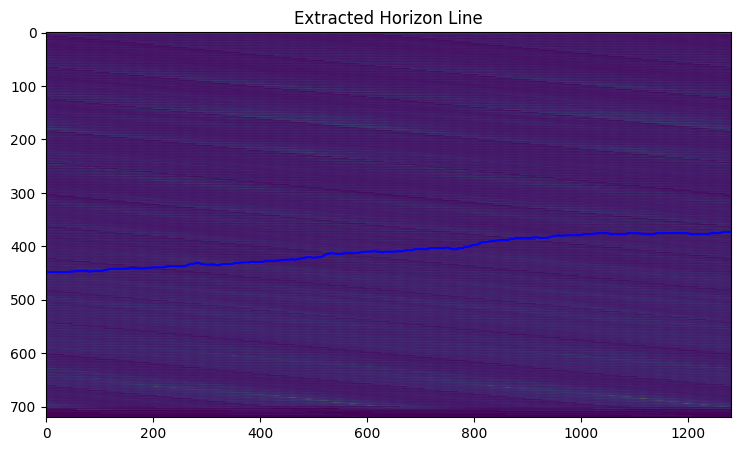

 58%|█████▊    | 21/36 [00:55<00:41,  2.74s/it]2025-05-22 18:45:17.790 Python[87855:14862839] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xd10b82080 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:17.808 Python[87855:14862370] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xd10b82550 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:17.809 Python[87855:14862370] GLDRendererMetal command buffer completion error: Error Domain

211 14644.018266855583


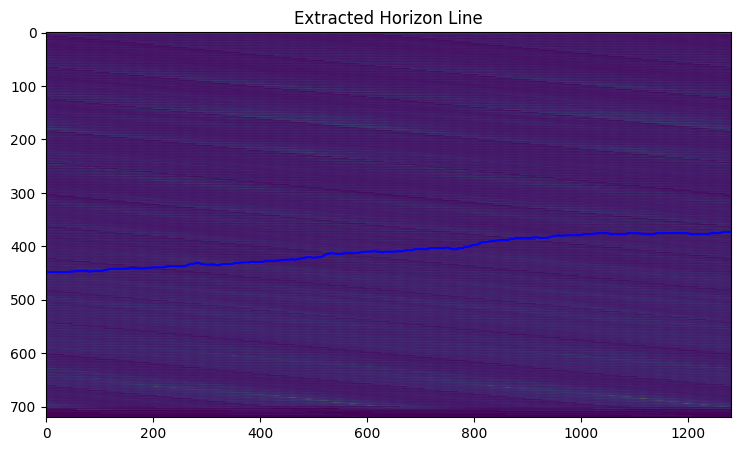

 61%|██████    | 22/36 [00:58<00:38,  2.73s/it]2025-05-22 18:45:20.498 Python[87855:14862082] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xd3092f3b0 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:20.521 Python[87855:14863147] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xc4fd7a570 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:20.522 Python[87855:14863147] GLDRendererMetal command buffer completion error: Error Domain

221 14644.018266855583


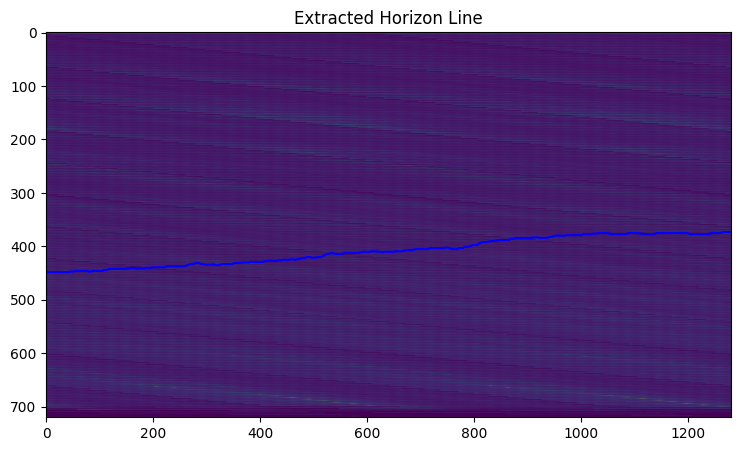

 64%|██████▍   | 23/36 [01:00<00:35,  2.73s/it]2025-05-22 18:45:23.242 Python[87855:14863146] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xc9d922790 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:23.259 Python[87855:14864060] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xd17a49610 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:23.259 Python[87855:14864060] GLDRendererMetal command buffer completion error: Error Domain

231 14644.018266855583


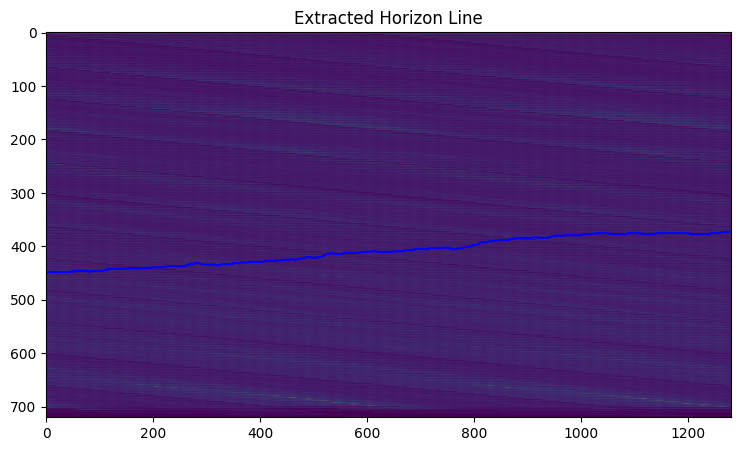

 67%|██████▋   | 24/36 [01:03<00:32,  2.73s/it]2025-05-22 18:45:25.988 Python[87855:14862092] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xcc676c4c0 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:26.005 Python[87855:14863140] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xcde89cf00 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:26.009 Python[87855:14863140] GLDRendererMetal command buffer completion error: Error Domain

241 14644.018266855583


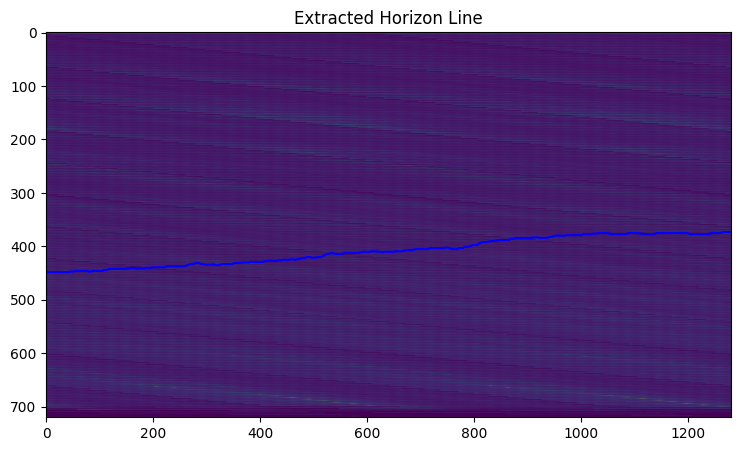

 69%|██████▉   | 25/36 [01:06<00:30,  2.74s/it]2025-05-22 18:45:28.745 Python[87855:14863139] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xcde8b6a80 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:28.762 Python[87855:14864063] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xd87f1c790 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:28.763 Python[87855:14864063] GLDRendererMetal command buffer completion error: Error Domain

251 14644.018266855583


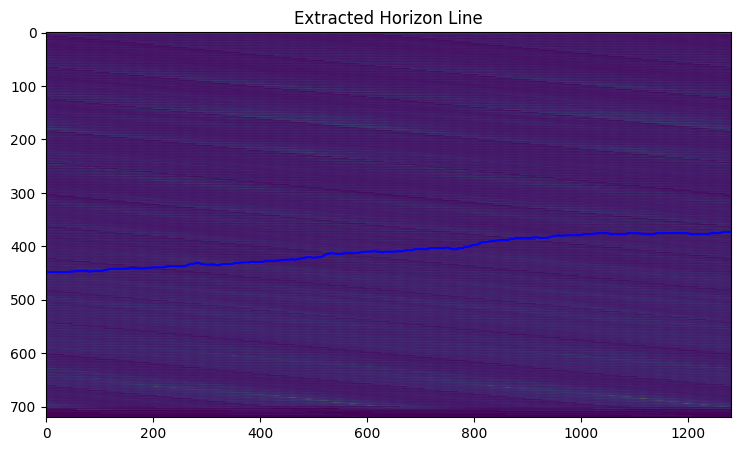

 72%|███████▏  | 26/36 [01:09<00:27,  2.75s/it]2025-05-22 18:45:31.540 Python[87855:14863139] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xd5fe6e9f0 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:31.558 Python[87855:14863140] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xd30961240 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:31.558 Python[87855:14863140] GLDRendererMetal command buffer completion error: Error Domain

261 14644.018266855583


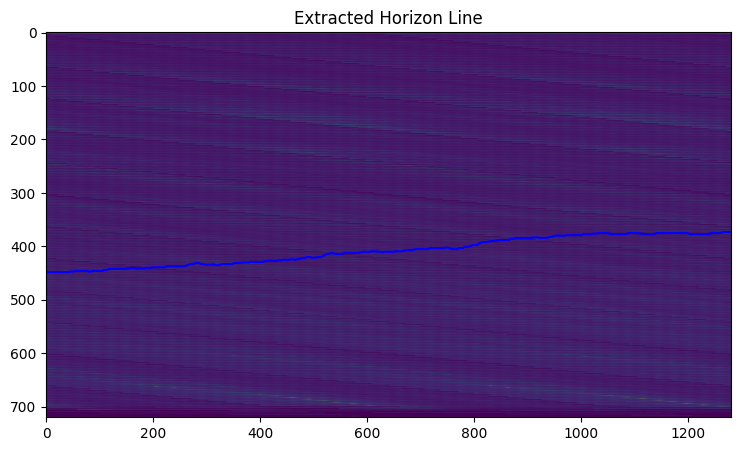

 75%|███████▌  | 27/36 [01:11<00:24,  2.76s/it]2025-05-22 18:45:34.313 Python[87855:14863145] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xcde882b20 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:34.333 Python[87855:14864061] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xcc6769b70 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:34.334 Python[87855:14864061] GLDRendererMetal command buffer completion error: Error Domain

271 14644.018266855583


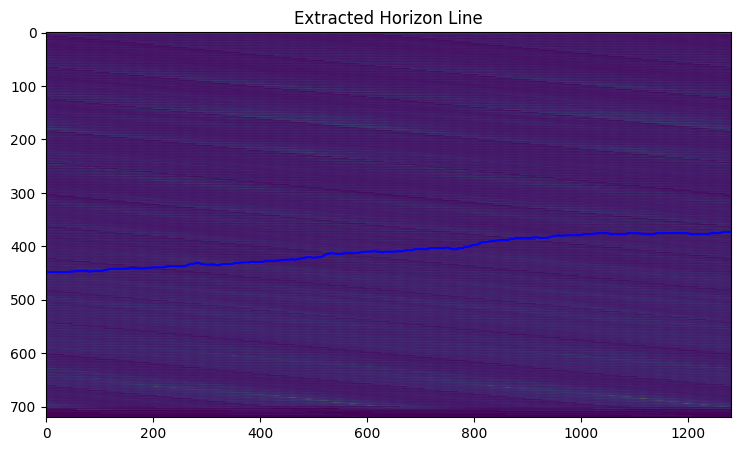

 78%|███████▊  | 28/36 [01:14<00:22,  2.77s/it]2025-05-22 18:45:37.088 Python[87855:14863143] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xd10bf5180 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:37.109 Python[87855:14864061] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xd10bf52b0 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:37.110 Python[87855:14864061] GLDRendererMetal command buffer completion error: Error Domain

281 14644.018266855583


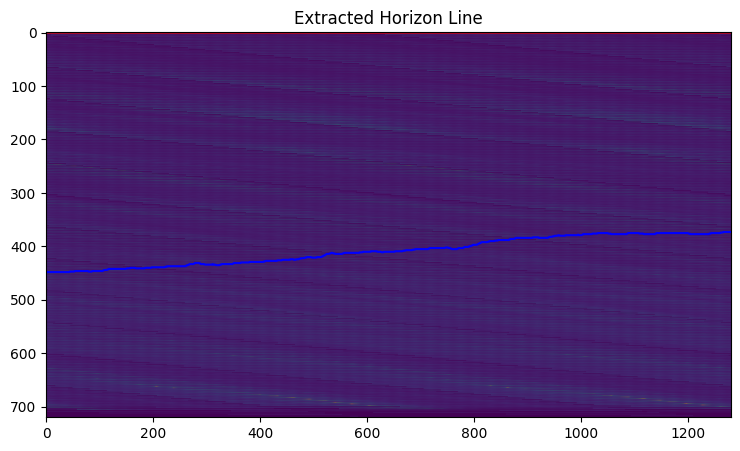

 81%|████████  | 29/36 [01:17<00:19,  2.77s/it]2025-05-22 18:45:39.867 Python[87855:14864064] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xd17ab5270 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:39.884 Python[87855:14864058] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xc9d9c95d0 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:39.885 Python[87855:14864058] GLDRendererMetal command buffer completion error: Error Domain

291 14644.018266855583


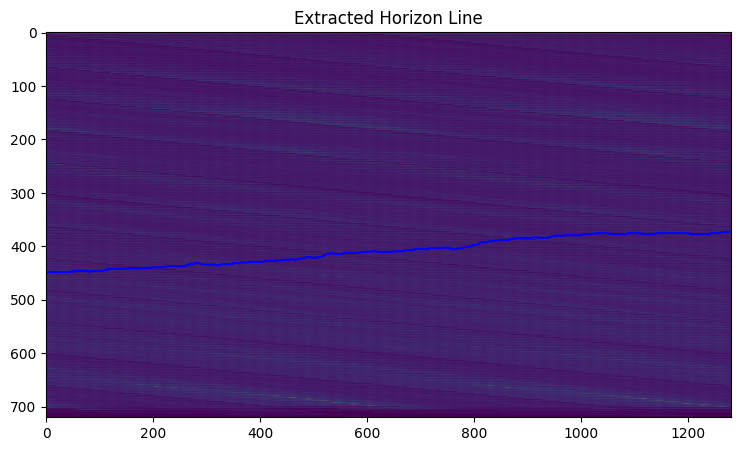

 83%|████████▎ | 30/36 [01:20<00:16,  2.79s/it]2025-05-22 18:45:42.688 Python[87855:14864936] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xc4fdee630 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:42.706 Python[87855:14864062] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xcde8eb530 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:42.707 Python[87855:14864062] GLDRendererMetal command buffer completion error: Error Domain

301 14644.018266855583


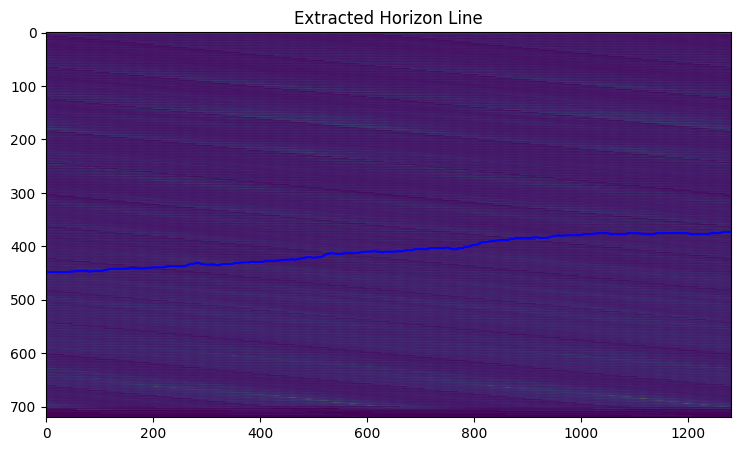

 86%|████████▌ | 31/36 [01:23<00:13,  2.78s/it]2025-05-22 18:45:45.449 Python[87855:14864064] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xd5feaf010 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:45.467 Python[87855:14863140] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xc9d9d9470 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:45.468 Python[87855:14863140] GLDRendererMetal command buffer completion error: Error Domain

311 14644.018266855583


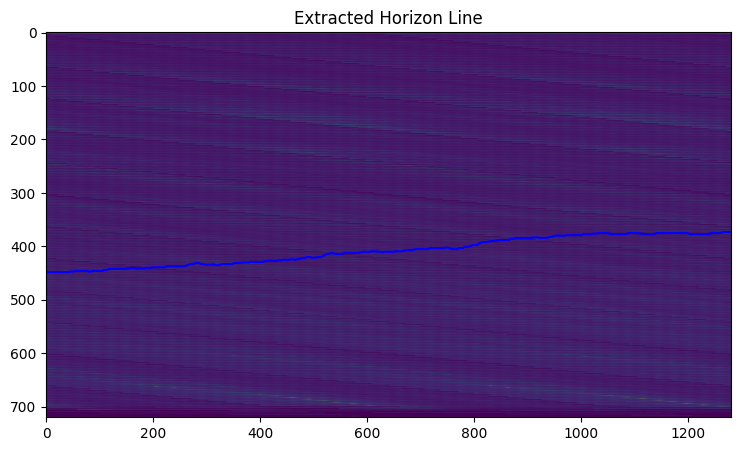

 89%|████████▉ | 32/36 [01:25<00:11,  2.77s/it]2025-05-22 18:45:48.216 Python[87855:14864483] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xd87f25290 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:48.233 Python[87855:14863146] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xd10bfbd10 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:48.234 Python[87855:14863146] GLDRendererMetal command buffer completion error: Error Domain

321 14644.018266855583


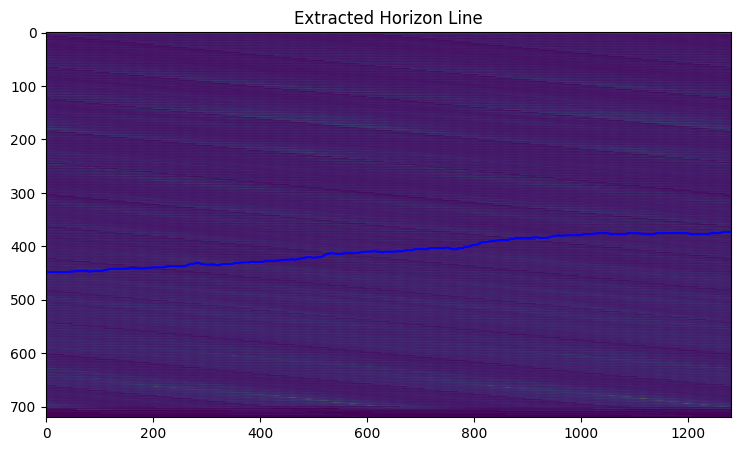

 92%|█████████▏| 33/36 [01:28<00:08,  2.77s/it]2025-05-22 18:45:50.948 Python[87855:14864058] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xe17f096f0 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:50.969 Python[87855:14864063] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xcc67e2670 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:50.970 Python[87855:14864063] GLDRendererMetal command buffer completion error: Error Domain

331 14644.018266855583


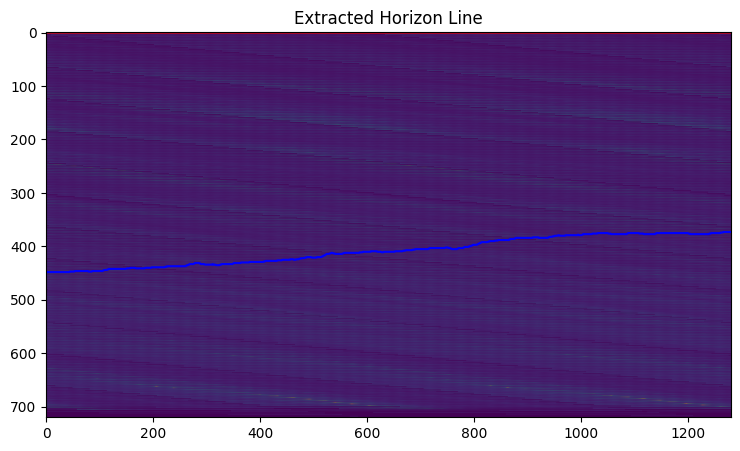

 94%|█████████▍| 34/36 [01:31<00:05,  2.76s/it]2025-05-22 18:45:53.719 Python[87855:14864482] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xd5feedc20 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:53.736 Python[87855:14864936] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xd5fee64f0 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:53.736 Python[87855:14864936] GLDRendererMetal command buffer completion error: Error Domain

341 14644.018266855583


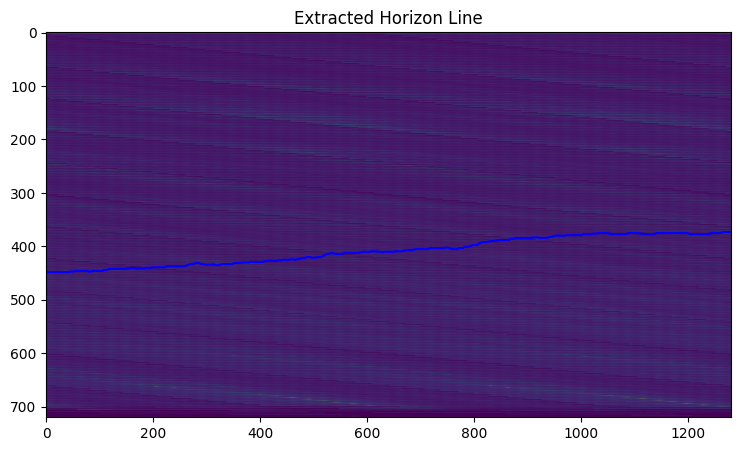

 97%|█████████▋| 35/36 [01:34<00:02,  2.76s/it]2025-05-22 18:45:56.451 Python[87855:14864064] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xe17e33cf0 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:56.468 Python[87855:14863147] GLDRendererMetal command buffer completion error: Error Domain=MTLCommandBufferErrorDomain Code=8 "Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)" UserInfo={NSLocalizedDescription=Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory), NSUnderlyingError=0xcc67e58a0 {Error Domain=IOGPUCommandQueueErrorDomain Code=8 "(null)"}}
2025-05-22 18:45:56.469 Python[87855:14863147] GLDRendererMetal command buffer completion error: Error Domain

351 14644.018266855583


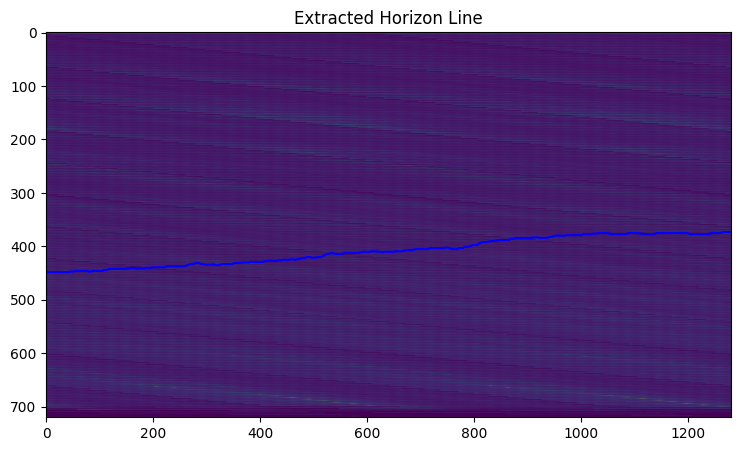

100%|██████████| 36/36 [01:36<00:00,  2.69s/it]


In [147]:


for azimuth in tqdm(range(1,360, 10)):


    dem_depth = get_dem_proj(dem, test_img, test_img_res, cam_info, azimuth, fov_x, fov_y)
    mm = dem_depth.max()

    dem_depth = dem_depth/mm
    horizon_line = np.argmax(dem_depth <0.5, axis=0)
    dst = dtw.distance(horizon_line, horizon_line_img)
    print(azimuth, dst)
    plt.figure(figsize=(10, 5))
    plt.imshow(dem_depth, cmap='viridis')
    plt.plot(horizon_line, color='red')
    plt.plot(horizon_line_img, color='blue')

    plt.title("Extracted Horizon Line")

    plt.show()
